In [2]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision
import torch
from torchvision import transforms

# General train func

In [3]:
def train_classifier(model, train_data, val_data, hyperparams):

    # Deals with model updates. Adam is more effective than SGD.
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparams['lr'])    
    
    # Cross-entropy loss because we have 10 classes.
    # Note that the softmax is "baked into" this loss, so we should not
    # use a softmax at the end.

    loss_func = torch.nn.CrossEntropyLoss()
      
    # Some statistics.
    acc_history = []

    for epoch in range(hyperparams['n_epochs']):

        # Set the model in training mode, enabling dropout if we use that.
        model.train()
        
        loss_sum = 0

        # For each batch
        for Xbatch, Ybatch in tqdm(train_data):

            # Apply the model. We don't know at this point what the model is.
            # The output should be of the shape (batch_size, 10).
            outputs = model(Xbatch)
            
            # Apply the cross-entropy loss.
            loss = loss_func(outputs, Ybatch)

            # Update the model.
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_sum += loss.item()

        # Set the model in evaluation mode. Disables dropout if present.
        model.eval()
        with torch.no_grad(): # Disable gradient computations, speeds up computations and saves memory.
            # Compute the accuracy on the validation data.
            val_acc = predict_and_evaluate(model, val_data)
                
        mean_loss = loss_sum / len(train_data)

        acc_history.append(val_acc)
        
        print(f'Epoch {epoch+1}: loss = {mean_loss:.4f}, val acc = {val_acc:.4f}')
    
    return acc_history
        
    
# A utility function to compute accuracies during training.
def predict_and_evaluate(model, data):
    
    all_gold = []
    all_pred = []
    
    for Xbatch, Ybatch in data:
        outputs = model(Xbatch)
        predictions = outputs.argmax(dim=1)
        
        all_gold.extend(Ybatch.numpy())
        all_pred.extend(predictions.numpy())

    return accuracy_score(all_gold, all_pred) 

# Transform

In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),  # 随机水平翻转
    transforms.RandomRotation(10),      # 随机旋转
    transforms.RandomResizedCrop(128),  # 随机裁剪并调整为 128x128
    transforms.ToTensor(),              # 转换为 Tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 标准化
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Load Data with transforms

In [5]:
train_folder = ImageFolder('./a5_data/train', transform=transform)
train_loader = DataLoader(train_folder, batch_size=8, shuffle=True)

val_folder = ImageFolder('./a5_data/val', transform=val_transform)
val_loader = DataLoader(val_folder, batch_size=8, shuffle=True)

# for i in range(1):
#     plt.subplot(2,4,i+1)  
#     img = Xexamples[i].numpy().transpose(1, 2, 0)  
#     print(img.shape)
#     print(Yexamples[i])
#     plt.imshow(img, interpolation='none')
#     plt.title('NV' if Yexamples[i] else 'MEL')
#     plt.xticks([])
#     plt.yticks([])

# Models

In [14]:
torch.random.manual_seed(2) # for reproducibility

## Baseline Cnn model

In [6]:
# cnn_model = nn.Sequential(
#     # 输入: (3, 128, 128) → 输出: (16, 128, 128)
#     nn.Conv2d(3, 16, kernel_size=3, padding=1), 
#     nn.BatchNorm2d(16),  # 加入 BatchNorm
#     nn.ReLU(),
#     nn.MaxPool2d(2),  # 输出: (16, 64, 64)

#     # 输入: (16, 64, 64) → 输出: (32, 64, 64)
#     nn.Conv2d(16, 32, kernel_size=3, padding=1),
#     nn.BatchNorm2d(32),
#     nn.ReLU(),
#     nn.MaxPool2d(2),  # 输出: (32, 32, 32)

#     # 输入: (32, 32, 32) → 输出: (64, 32, 32)
#     nn.Conv2d(32, 64, kernel_size=3, padding=1),
#     nn.BatchNorm2d(64),
#     nn.ReLU(),
#     nn.MaxPool2d(2),  # 输出: (64, 16, 16)

#     # 输入: (64, 16, 16) → 输出: (128, 16, 16)
#     nn.Conv2d(64, 128, kernel_size=3, padding=1),
#     nn.BatchNorm2d(128),
#     nn.ReLU(),
#     nn.MaxPool2d(2),  # 输出: (128, 8, 8)

#     # 展平层，将 (128, 8, 8) 展平为一维向量 (8192,)
#     nn.Flatten(),

#     # 全连接层: 输入 8192 → 输出 512
#     nn.Linear(128 * 8 * 8, 512),  # 计算公式: 128 * 8 * 8 = 8192
#     nn.ReLU(),
#     nn.Dropout(0.5),  # 添加 Dropout，防止过拟合

#     # 第二个全连接层: 输入 512 → 输出 1 (Sigmoid 激活)
#     nn.Linear(512, 2),
# )


In [7]:
# Use 1 epoch to test roughly
# history = train_classifier(cnn_model, train_loader, val_loader, {'lr': 1e-3, 'n_epochs': 1})

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 804/804 [01:58<00:00,  6.78it/s]


Epoch 1: loss = 0.6477, val acc = 0.7444


## Model with ResNet

In [23]:
class CustomResNetBlock(nn.Module):
    def __init__(self, in_channels, mid_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(mid_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 残差
        self.shortcut = nn.Sequential()
        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                # 这里核函数应该size为1 无空间信息提取，仅调整通道数和分辨率
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out += identity
        out = self.relu(out)
        return out

cnn_model = nn.Sequential(
    CustomResNetBlock(3, 16, 32, stride=1),
    CustomResNetBlock(32, 64, 128, stride=2),
    CustomResNetBlock(128, 256, 512, stride=2),
    CustomResNetBlock(512, 256, 512, stride=1),

    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),

    nn.Linear(512, 20),
    nn.ReLU(),
    nn.Dropout(0.5),
    
    nn.Linear(20, 2),
)    

In [24]:
# Use 1 epoch to test roughly
history = train_classifier(cnn_model, train_loader, val_loader, {'lr': 1e-3, 'n_epochs': 1})

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 804/804 [17:57<00:00,  1.34s/it]


Epoch 1: loss = 0.6064, val acc = 0.7268


# Simple Validation

Label: 1


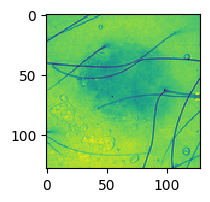

In [12]:
# examples = enumerate(val_loader)
# batch_idx, (example_data, example_targets) = next(examples)

# i = 7
# example_image = example_data[[i]]

# print('Label:', example_targets[i].item())

# plt.figure(figsize=(2, 2))
# plt.imshow(example_image[0, 0], interpolation='none');

In [13]:
# scores = cnn_model(example_image)
    
# #scores
# scores.argmax().item()

1